# Diverse Spanish Speech Dataset Analysis

This notebook provides a comprehensive analysis of the dataset characteristics including duration, gender distribution, disease distribution, and intelligibility levels.

In [ ]:
import pandas as pd
import seaborn as sns
from pathlib import Path
import matplotlib.pyplot as plt

sns.set_style("whitegrid")
COLORBLIND_PALETTE = ['#4477AA', '#EE6677', '#228833', '#CCBB44', '#66CCEE', '#AA3377', '#BBBBBB']
sns.set_palette(COLORBLIND_PALETTE)
GENDER_COLORS = {
    'Female': '#EE6677',
    'Male': '#4477AA'
}

plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.size'] = 12
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.labelsize'] = 13
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['legend.fontsize'] = 11
plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['lines.linewidth'] = 2.5
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['xtick.major.size'] = 6
plt.rcParams['ytick.major.size'] = 6

# Create output directory for images if it doesn't exist
OUTPUT_DIR = Path("../notebooks/images/dss/")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

def save_figure(fig, name, dpi=300, format='pdf'):
    """Save figure in high quality PDF format for publication."""
    filepath = OUTPUT_DIR / f"{name}.{format}"
    fig.tight_layout()
    fig.savefig(filepath, dpi=dpi, format=format, bbox_inches='tight', pad_inches=0.1)
    print(f"Saved: {filepath}")
    return filepath

## Load Data

In [ ]:
# Load dataset
df = pd.read_csv("../data/s-diverse.tsv", sep="\t")

# Replace PARKINSON with PD for consistency
df['Disease'] = df['Disease'].replace('PARKINSON', 'PD')

print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (444, 9)


,Speaker_ID,Sample_ID,Disease,Sex,Intelligibility,Transcription,Source,Timestamp,Duration
0,ALS_F01,ALS_F01_01,ALS,Female,High/Medium,Me llamo Mari Carmen Berenguer Lafuente. Empec...,https://youtu.be/ERSM9zh7BP8,00:00:00 - 00:00:47,47.0
1,ALS_F01,ALS_F01_02,ALS,Female,High/Medium,"No me dijeron en ningún momento ""es ELA"". Me h...",https://youtu.be/ERSM9zh7BP8,00:01:23 - 00:02:07,44.0
2,ALS_F01,ALS_F01_03,ALS,Female,High/Medium,Al día siguiente leí el informe y ahí fue dond...,https://youtu.be/ERSM9zh7BP8,00:02:07 - 00:02:28,21.0
3,ALS_F01,ALS_F01_04,ALS,Female,High/Medium,Yo he sido profesora. En los veranos me gustab...,https://youtu.be/ERSM9zh7BP8,00:02:51 - 00:03:14,23.0
4,ALS_F01,ALS_F01_05,ALS,Female,High/Medium,Ya estoy. Y ahora me voy. Adiós.,https://youtu.be/ERSM9zh7BP8,00:03:56 - 00:04:06,10.0


In [3]:
# General stats of df: counts, mean length of audios, sex balancing, illness
n_sample = len(df.index)
n_male = (df['Sex'] == 'Male').sum() if 'Sex' in df.columns else None
n_female = (df['Sex'] == 'Female').sum() if 'Sex' in df.columns else None
mean_audio_len = df['Duration_sec'].mean() if 'Duration_sec' in df.columns else None
total_duration = df['Duration_sec'].sum() if 'Duration_sec' in df.columns else None
illness_counts = df['Disease'].value_counts() if 'Disease' in df.columns else None

# Unique number of speakers
if 'Speaker_ID' in df.columns:
    n_speakers = df['Speaker_ID'].nunique()
    print(f"Total unique speakers: {n_speakers}")

print(f"Total samples: {n_sample}")

# Gender distribution - both by count and duration
if n_male is not None and n_female is not None:
    print(f"\n--- Gender Distribution (by sample count) ---")
    print(f"Male: {n_male} ({n_male/n_sample*100:.1f}%) | Female: {n_female} ({n_female/n_sample*100:.1f}%)")
    
    if 'Duration_sec' in df.columns:
        male_duration = df[df['Sex'] == 'Male']['Duration_sec'].sum()
        female_duration = df[df['Sex'] == 'Female']['Duration_sec'].sum()
        print(f"\n--- Gender Distribution (by audio duration) ---")
        print(f"Male: {male_duration/60:.2f} min ({male_duration/total_duration*100:.1f}%) | Female: {female_duration/60:.2f} min ({female_duration/total_duration*100:.1f}%)")

if mean_audio_len is not None:
    print(f"\nMean audio length: {mean_audio_len:.2f} seconds")
    print(f"Total audio duration: {total_duration/60:.2f} minutes ({total_duration/3600:.2f} hours)")

# Disease distribution - both by count and duration
if illness_counts is not None:
    print("\n--- Disease Distribution (by sample count) ---")
    print("Samples per disease: ")
    print(illness_counts)
    print("\nPercentage per disease (by count):")
    print((illness_counts / n_sample * 100).round(2).astype(str) + '%')
    
    if 'Duration_sec' in df.columns:
        disease_duration = df.groupby('Disease')['Duration_sec'].sum().sort_values(ascending=False)
        print("\n--- Disease Distribution (by audio duration) ---")
        print("Duration per disease (minutes):")
        print((disease_duration / 60).round(2))
        print("\nPercentage per disease (by duration):")
        print((disease_duration / total_duration * 100).round(2).astype(str) + '%')

Total unique speakers: 22
Total samples: 444

--- Gender Distribution (by sample count) ---
Male: 385 (86.7%) | Female: 59 (13.3%)

--- Disease Distribution (by sample count) ---
Samples per disease: 
Disease
ALS       252
PD        111
STROKE     81
Name: count, dtype: int64

Percentage per disease (by count):
Disease
ALS       56.76%
PD         25.0%
STROKE    18.24%
Name: count, dtype: object


## Audio Duration Analysis

Saved: ../notebooks/images/dss/01_audio_duration_distribution.pdf


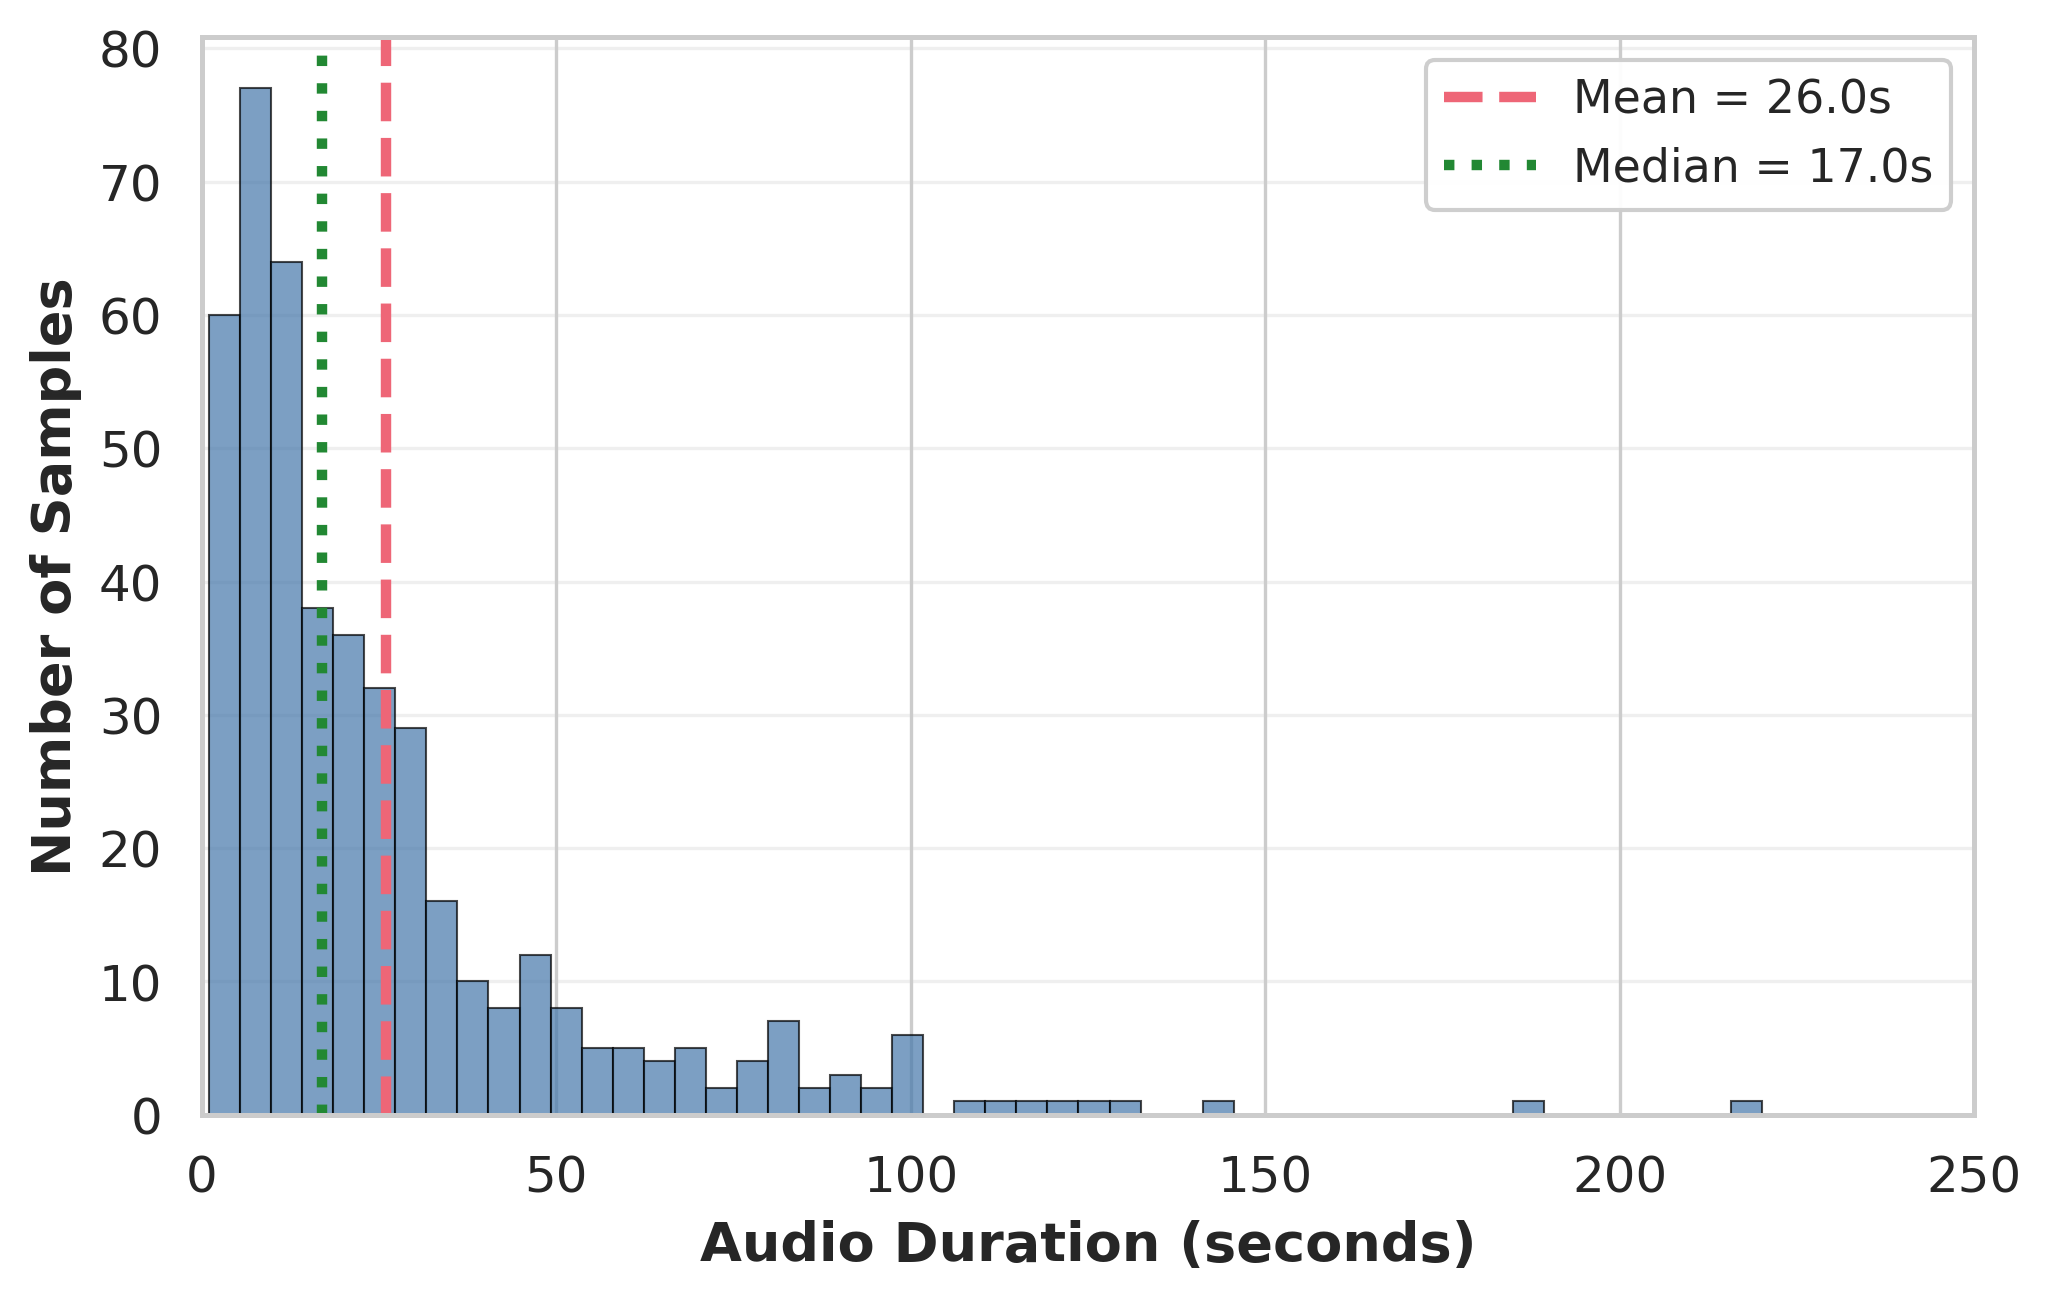

In [ ]:
# Audio Duration Distribution - Publication Quality (Histogram)
fig, ax = plt.subplots(figsize=(7, 4.5))
mean_len = df["Duration"].mean()
median_len = df["Duration"].median()

# Create histogram with color-blind friendly color
ax.hist(df["Duration"], bins=50, color=COLORBLIND_PALETTE[0], alpha=0.7, edgecolor='black', linewidth=0.5)
ax.axvline(mean_len, color=COLORBLIND_PALETTE[1], linestyle="--", linewidth=2.5, label=f"Mean = {mean_len:.1f}s")
ax.axvline(median_len, color=COLORBLIND_PALETTE[2], linestyle=":", linewidth=2.5, label=f"Median = {median_len:.1f}s")

ax.set_xlabel('Audio Duration (seconds)', fontsize=13, fontweight='bold')
ax.set_ylabel('Number of Samples', fontsize=13, fontweight='bold')
ax.set_xlim(left=0, right=250)
ax.legend(fontsize=11, framealpha=0.95, loc='upper right')
ax.grid(True, alpha=0.3, axis='y')
plt.show()

Saved: ../notebooks/images/dss/02_duration_per_disease.pdf


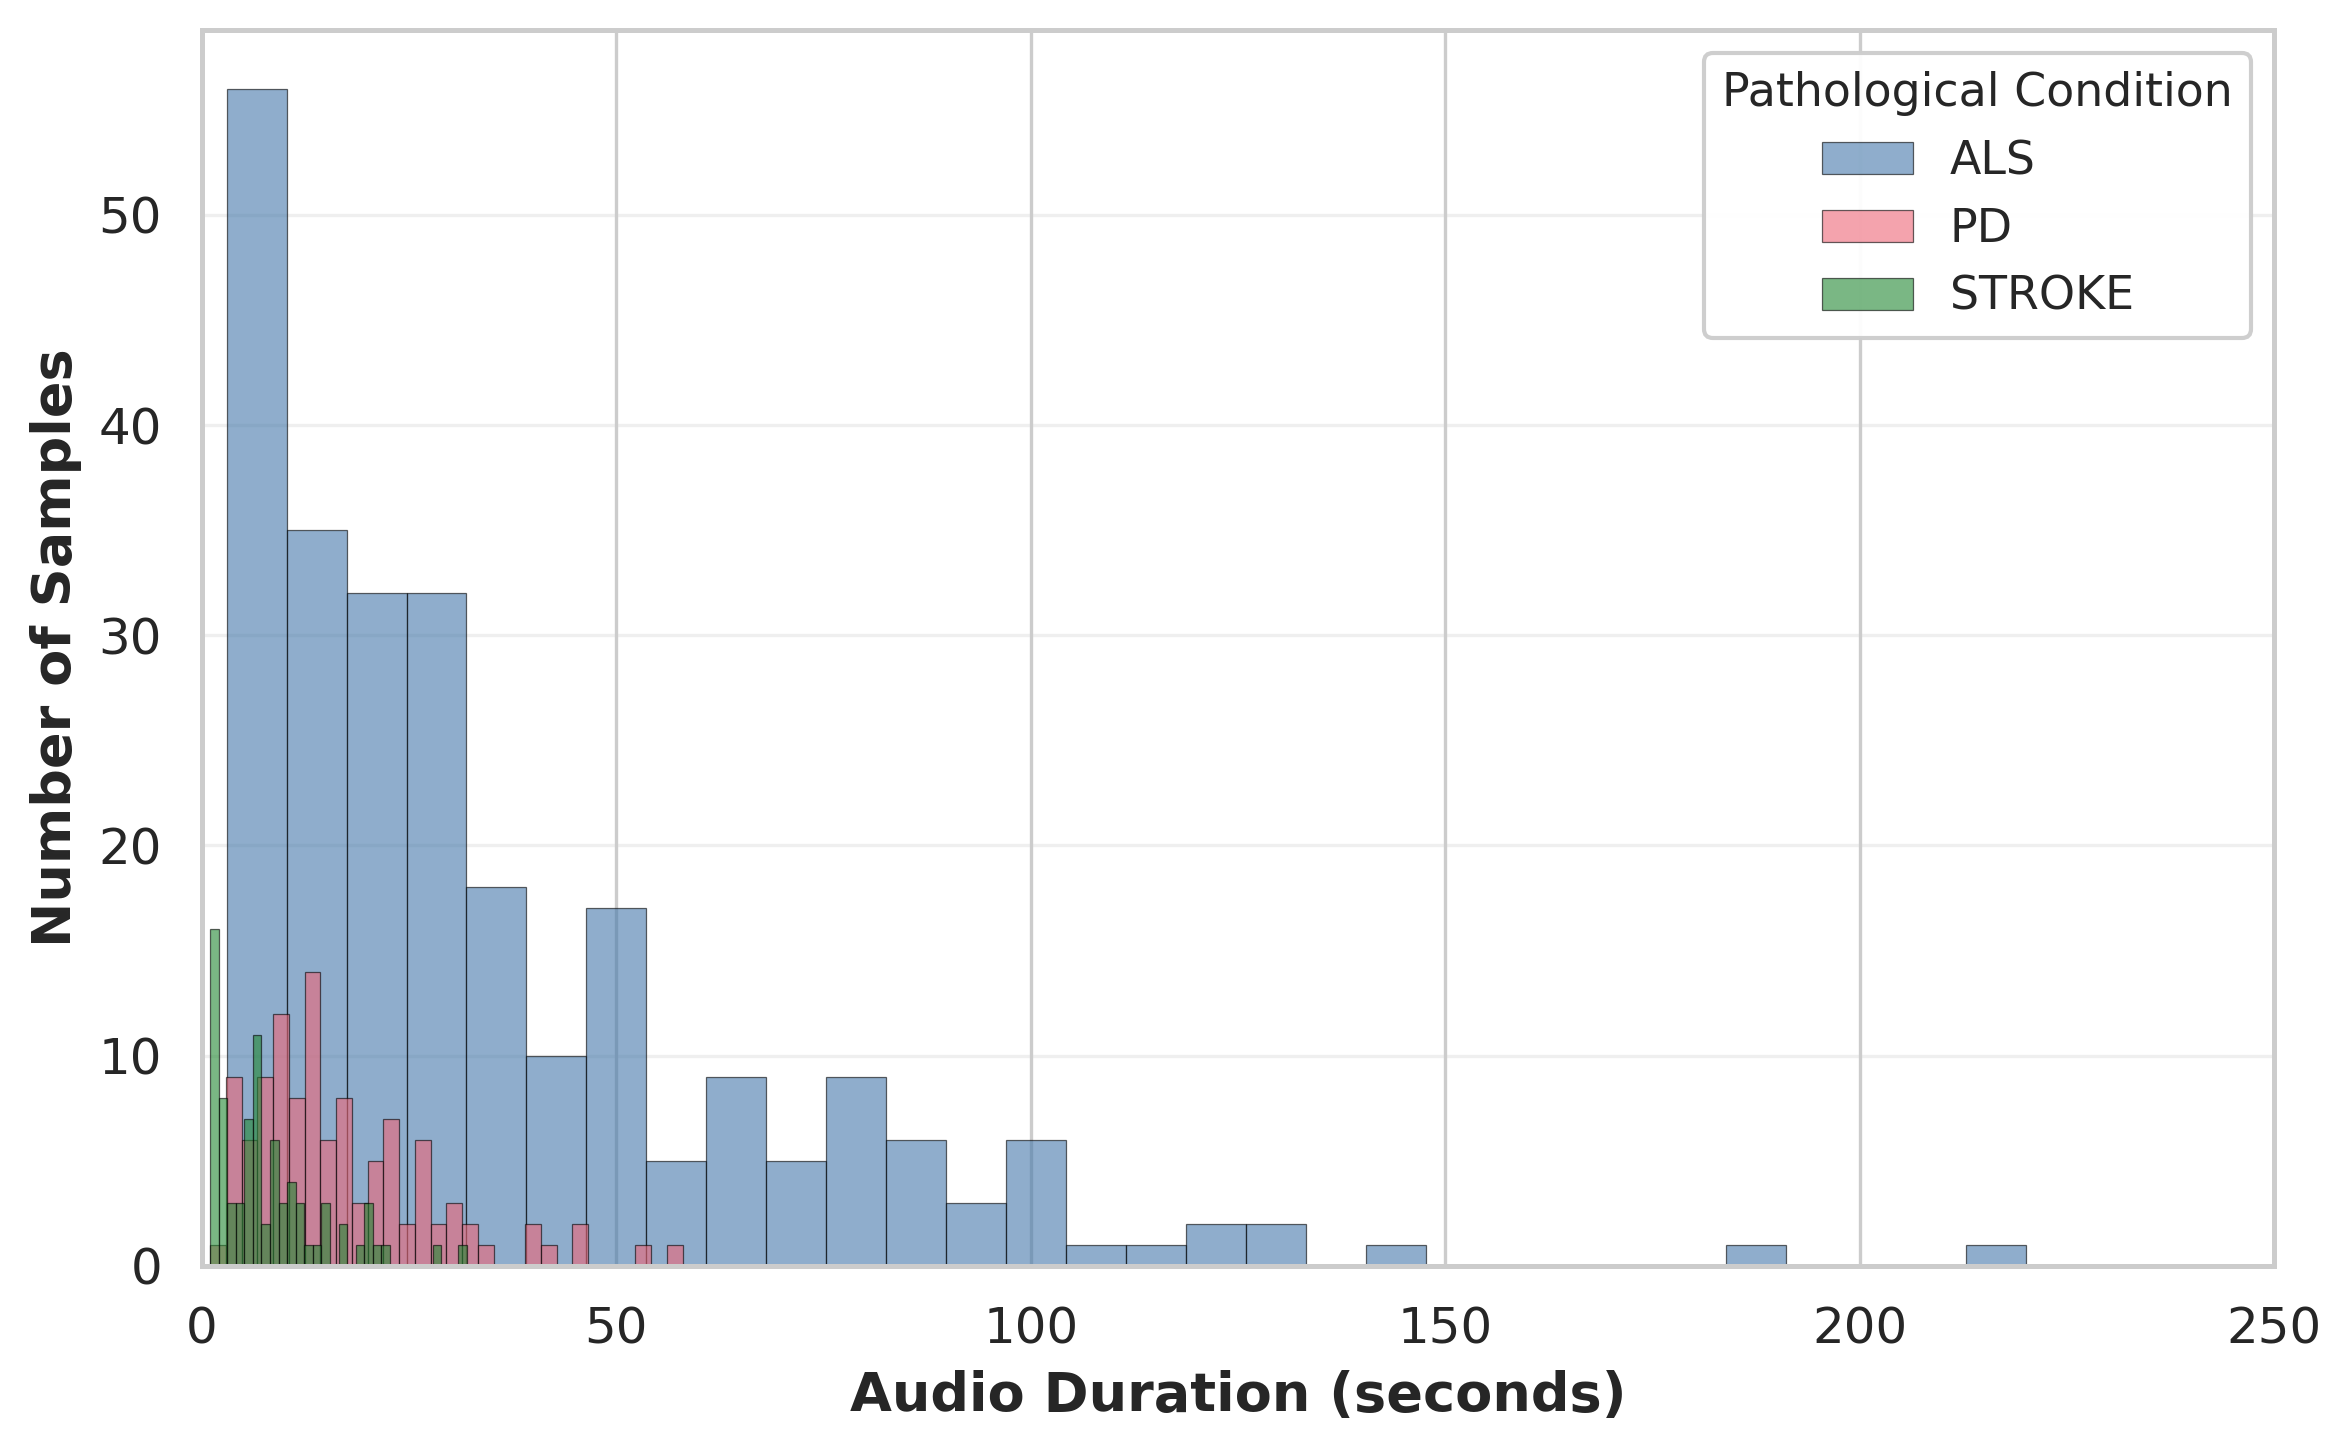

In [ ]:
# Duration Distribution per Disease - Publication Quality (Histogram)
if 'Disease' in df.columns and 'Duration' in df.columns:
    fig, ax = plt.subplots(figsize=(8, 5))
    diseases = sorted(df['Disease'].unique())
    # Use color-blind friendly palette
    colors = [COLORBLIND_PALETTE[i % len(COLORBLIND_PALETTE)] for i in range(len(diseases))]
    
    # Create overlapping histograms with transparency
    for i, illness in enumerate(diseases):
        disease_data = df[df['Disease'] == illness]['Duration']
        ax.hist(disease_data, bins=30, alpha=0.6, label=illness, color=colors[i], edgecolor='black', linewidth=0.3)
    
    ax.set_xlabel('Audio Duration (seconds)', fontsize=13, fontweight='bold')
    ax.set_ylabel('Number of Samples', fontsize=13, fontweight='bold')
    ax.set_xlim(left=0, right=250)
    ax.legend(title='Pathological Condition', fontsize=11, title_fontsize=11, framealpha=0.95, loc='upper right')
    ax.grid(True, alpha=0.3, axis='y')
    plt.show()
else:
    print('Required columns not found in dataframe.')

Disease: ALS | Correlation: 0.951
Disease: PD | Correlation: 0.946
Disease: STROKE | Correlation: 0.880
Saved: ../notebooks/images/dss/03_duration_vs_transcription_length.pdf


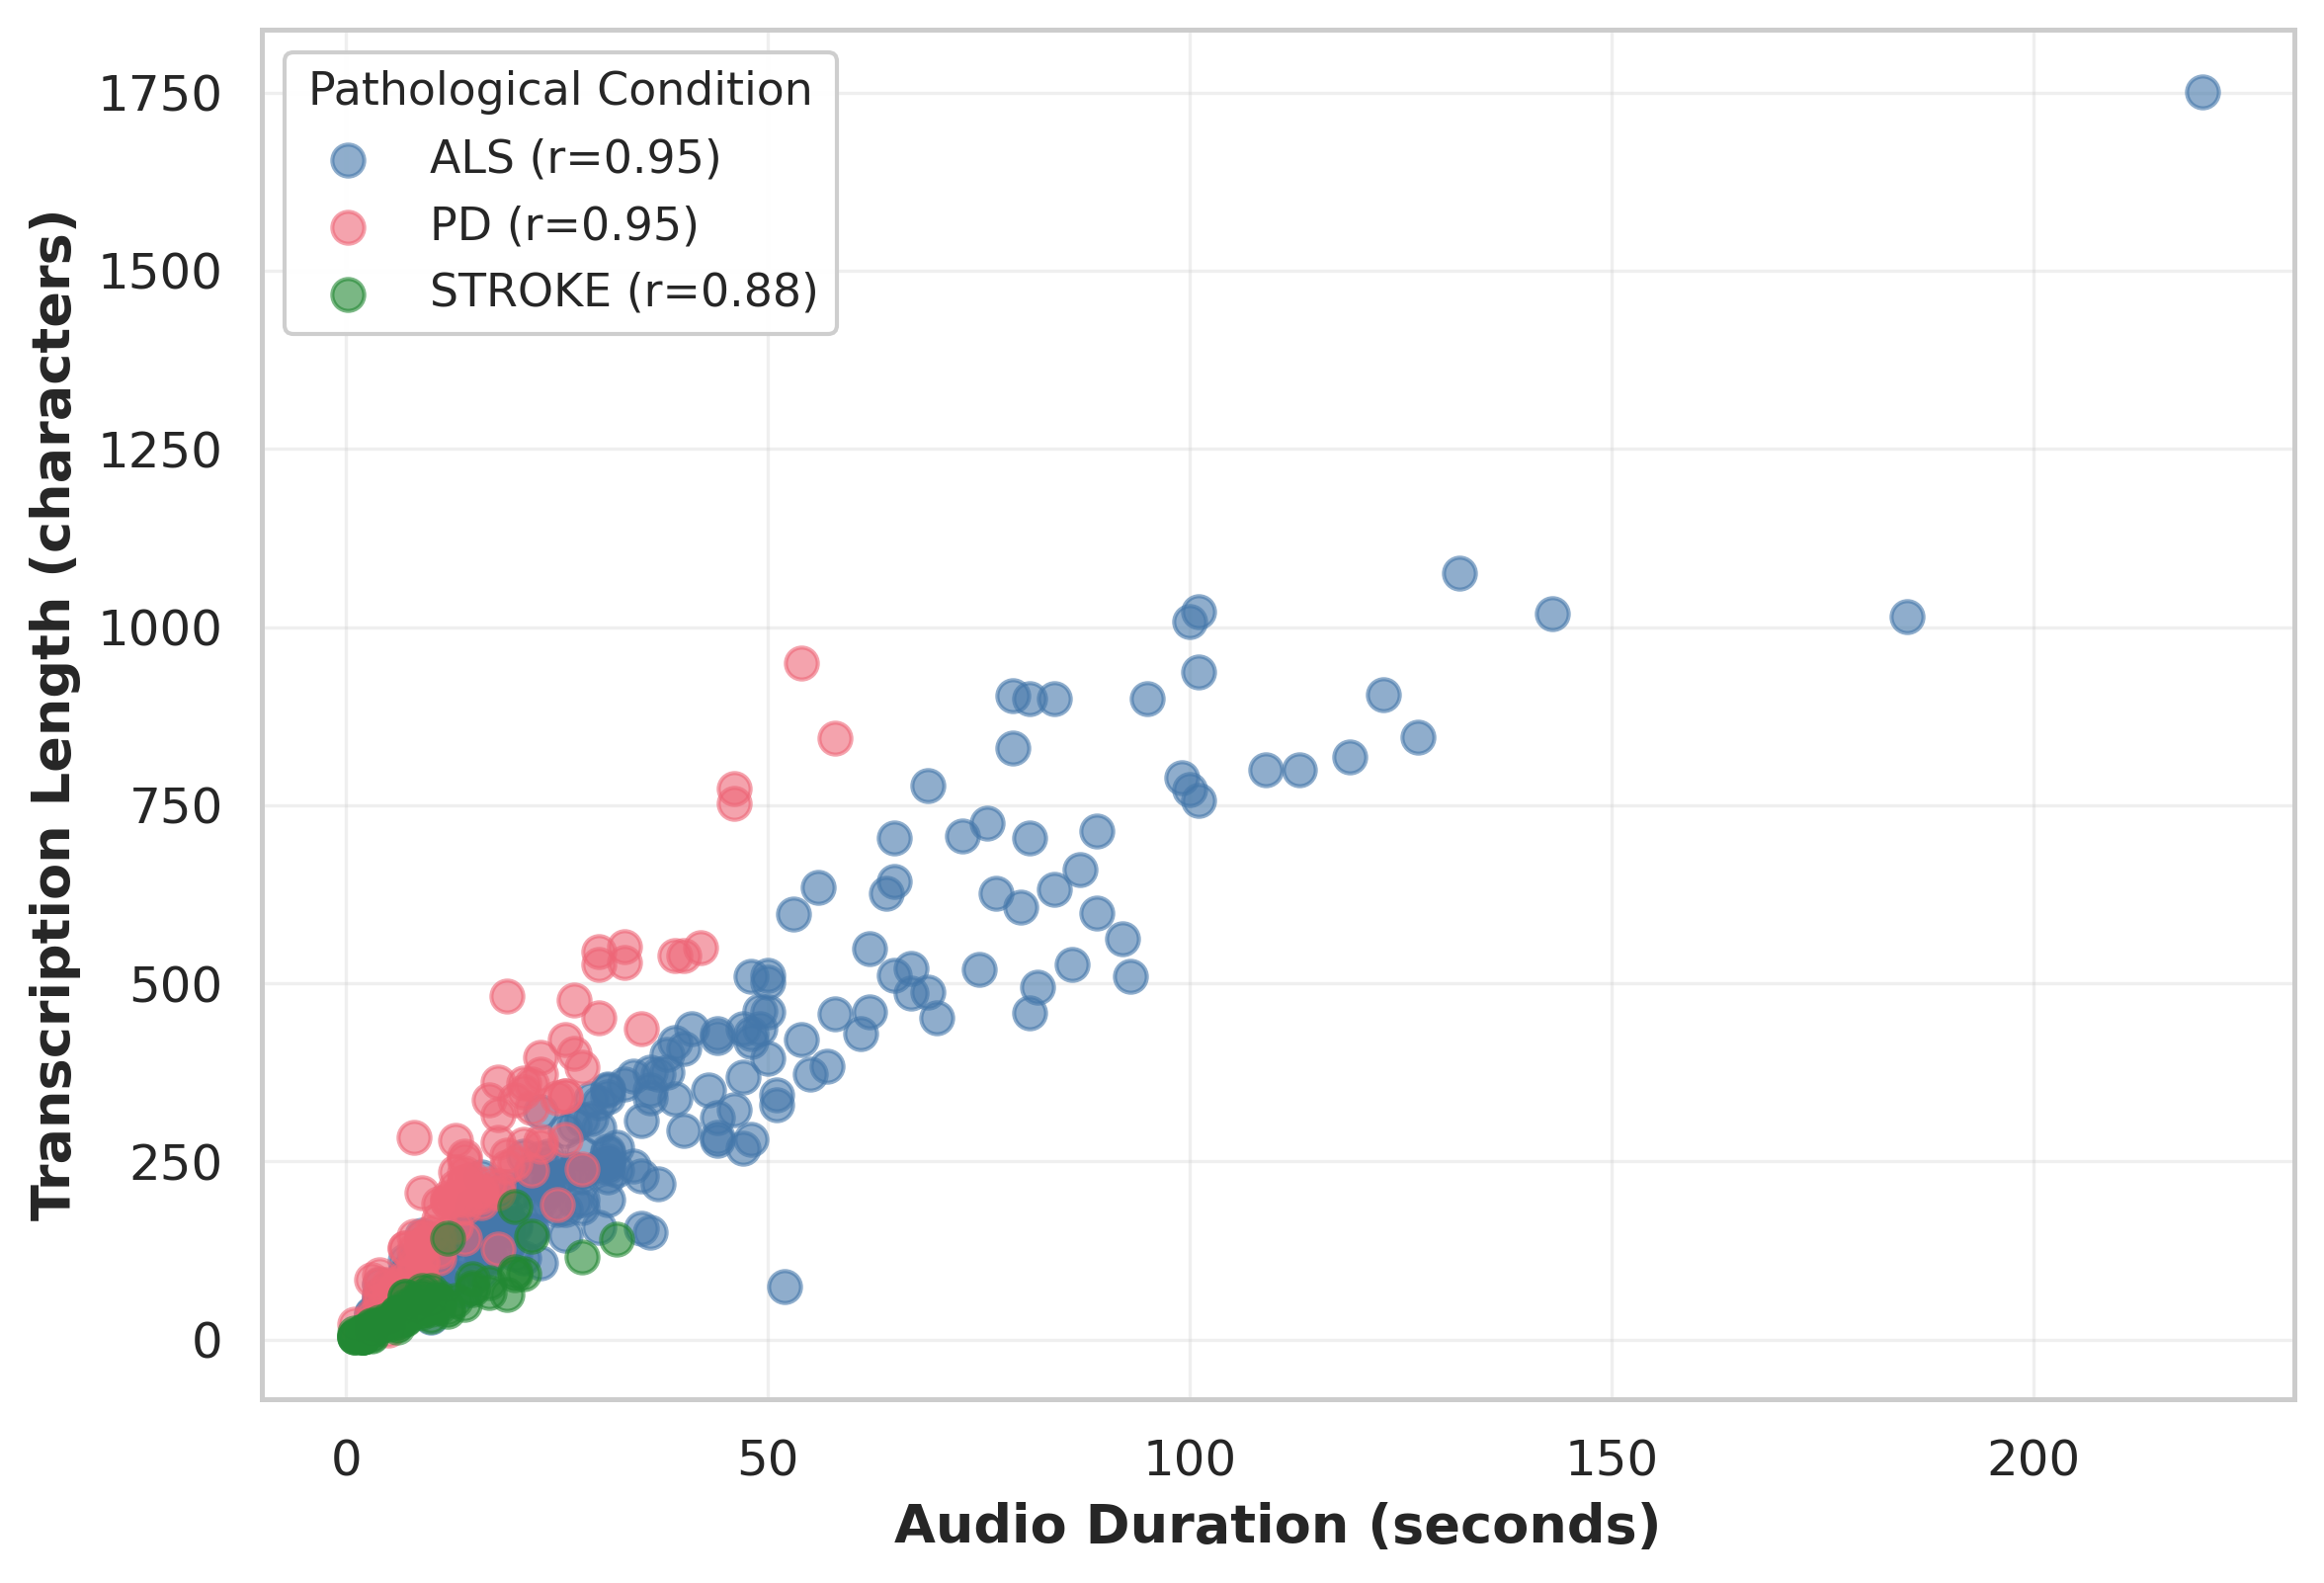

In [ ]:
# Correlation between Audio Duration and Text Length per Disease - Publication Quality
if 'Duration' in df.columns and 'Transcription' in df.columns and 'Disease' in df.columns:
    df['text_len'] = df['Transcription'].astype(str).apply(len)
    illnesses = df['Disease'].unique()
    fig, ax = plt.subplots(figsize=(8, 5.5))
    # Use color-blind friendly palette
    colors = [COLORBLIND_PALETTE[i % len(COLORBLIND_PALETTE)] for i in range(len(illnesses))]
    
    for i, illness in enumerate(illnesses):
        subdf = df[df['Disease'] == illness]
        corr = subdf['Duration'].corr(subdf['text_len'])
        print(f'Disease: {illness} | Correlation: {corr:.3f}')
        ax.scatter(subdf['Duration'], subdf['text_len'], alpha=0.6, s=60, 
                  label=f'{illness} (r={corr:.2f})', color=colors[i])
    
    ax.set_xlabel('Audio Duration (seconds)', fontsize=13, fontweight='bold')
    ax.set_ylabel('Transcription Length (characters)', fontsize=13, fontweight='bold')
    ax.legend(title='Pathological Condition', fontsize=11, title_fontsize=11, framealpha=0.95, loc='upper left')
    ax.grid(True, alpha=0.3)
    plt.show()
else:
    print('Required columns not found in dataframe.')

## Sample Distribution

In [ ]:
## Dataset Summary Statistics

# General statistics for the paper
n_sample = len(df.index)
n_speakers = df['Speaker_ID'].nunique() if 'Speaker_ID' in df.columns else None
n_male = (df['Sex'] == 'Male').sum() if 'Sex' in df.columns else None
n_female = (df['Sex'] == 'Female').sum() if 'Sex' in df.columns else None
mean_audio_len = df['Duration'].mean() if 'Duration' in df.columns else None
total_duration = df['Duration'].sum()
illness_counts = df['Disease'].value_counts() if 'Disease' in df.columns else None

print("="*60)
print("S-DiverSe - SUMMARY STATISTICS")
print("="*60)
print(f"Total samples: {n_sample}")
if n_speakers is not None:
    print(f"Unique speakers: {n_speakers}")
if n_male is not None and n_female is not None:
    print(f"Gender distribution: Female {n_female} ({n_female/n_sample*100:.1f}%) | Male {n_male} ({n_male/n_sample*100:.1f}%)")
if mean_audio_len is not None:
    print(f"Mean audio duration: {mean_audio_len:.2f} seconds")
print(f"Total dataset duration: {total_duration/3600:.2f} hours")
print("\nSamples per pathological condition:")
for condition, count in illness_counts.items():
    print(f"  {condition}: {count} ({count/n_sample*100:.1f}%)")
print("="*60)

DIVERSE SPANISH SPEECH DATASET - SUMMARY STATISTICS
Total samples: 444
Unique speakers: 22
Gender distribution: Female 59 (13.3%) | Male 385 (86.7%)
Mean audio duration: 26.00 seconds
Total dataset duration: 3.21 hours

Samples per pathological condition:
  ALS: 252 (56.8%)
  PD: 111 (25.0%)
  STROKE: 81 (18.2%)


## Sex Distribution


Gender distribution per disease:
Sex      Female  Male
Disease              
ALS          13   228
PD           30    67
STROKE       12    69
Saved: ../notebooks/images/dss/04_gender_distribution_per_disease.pdf


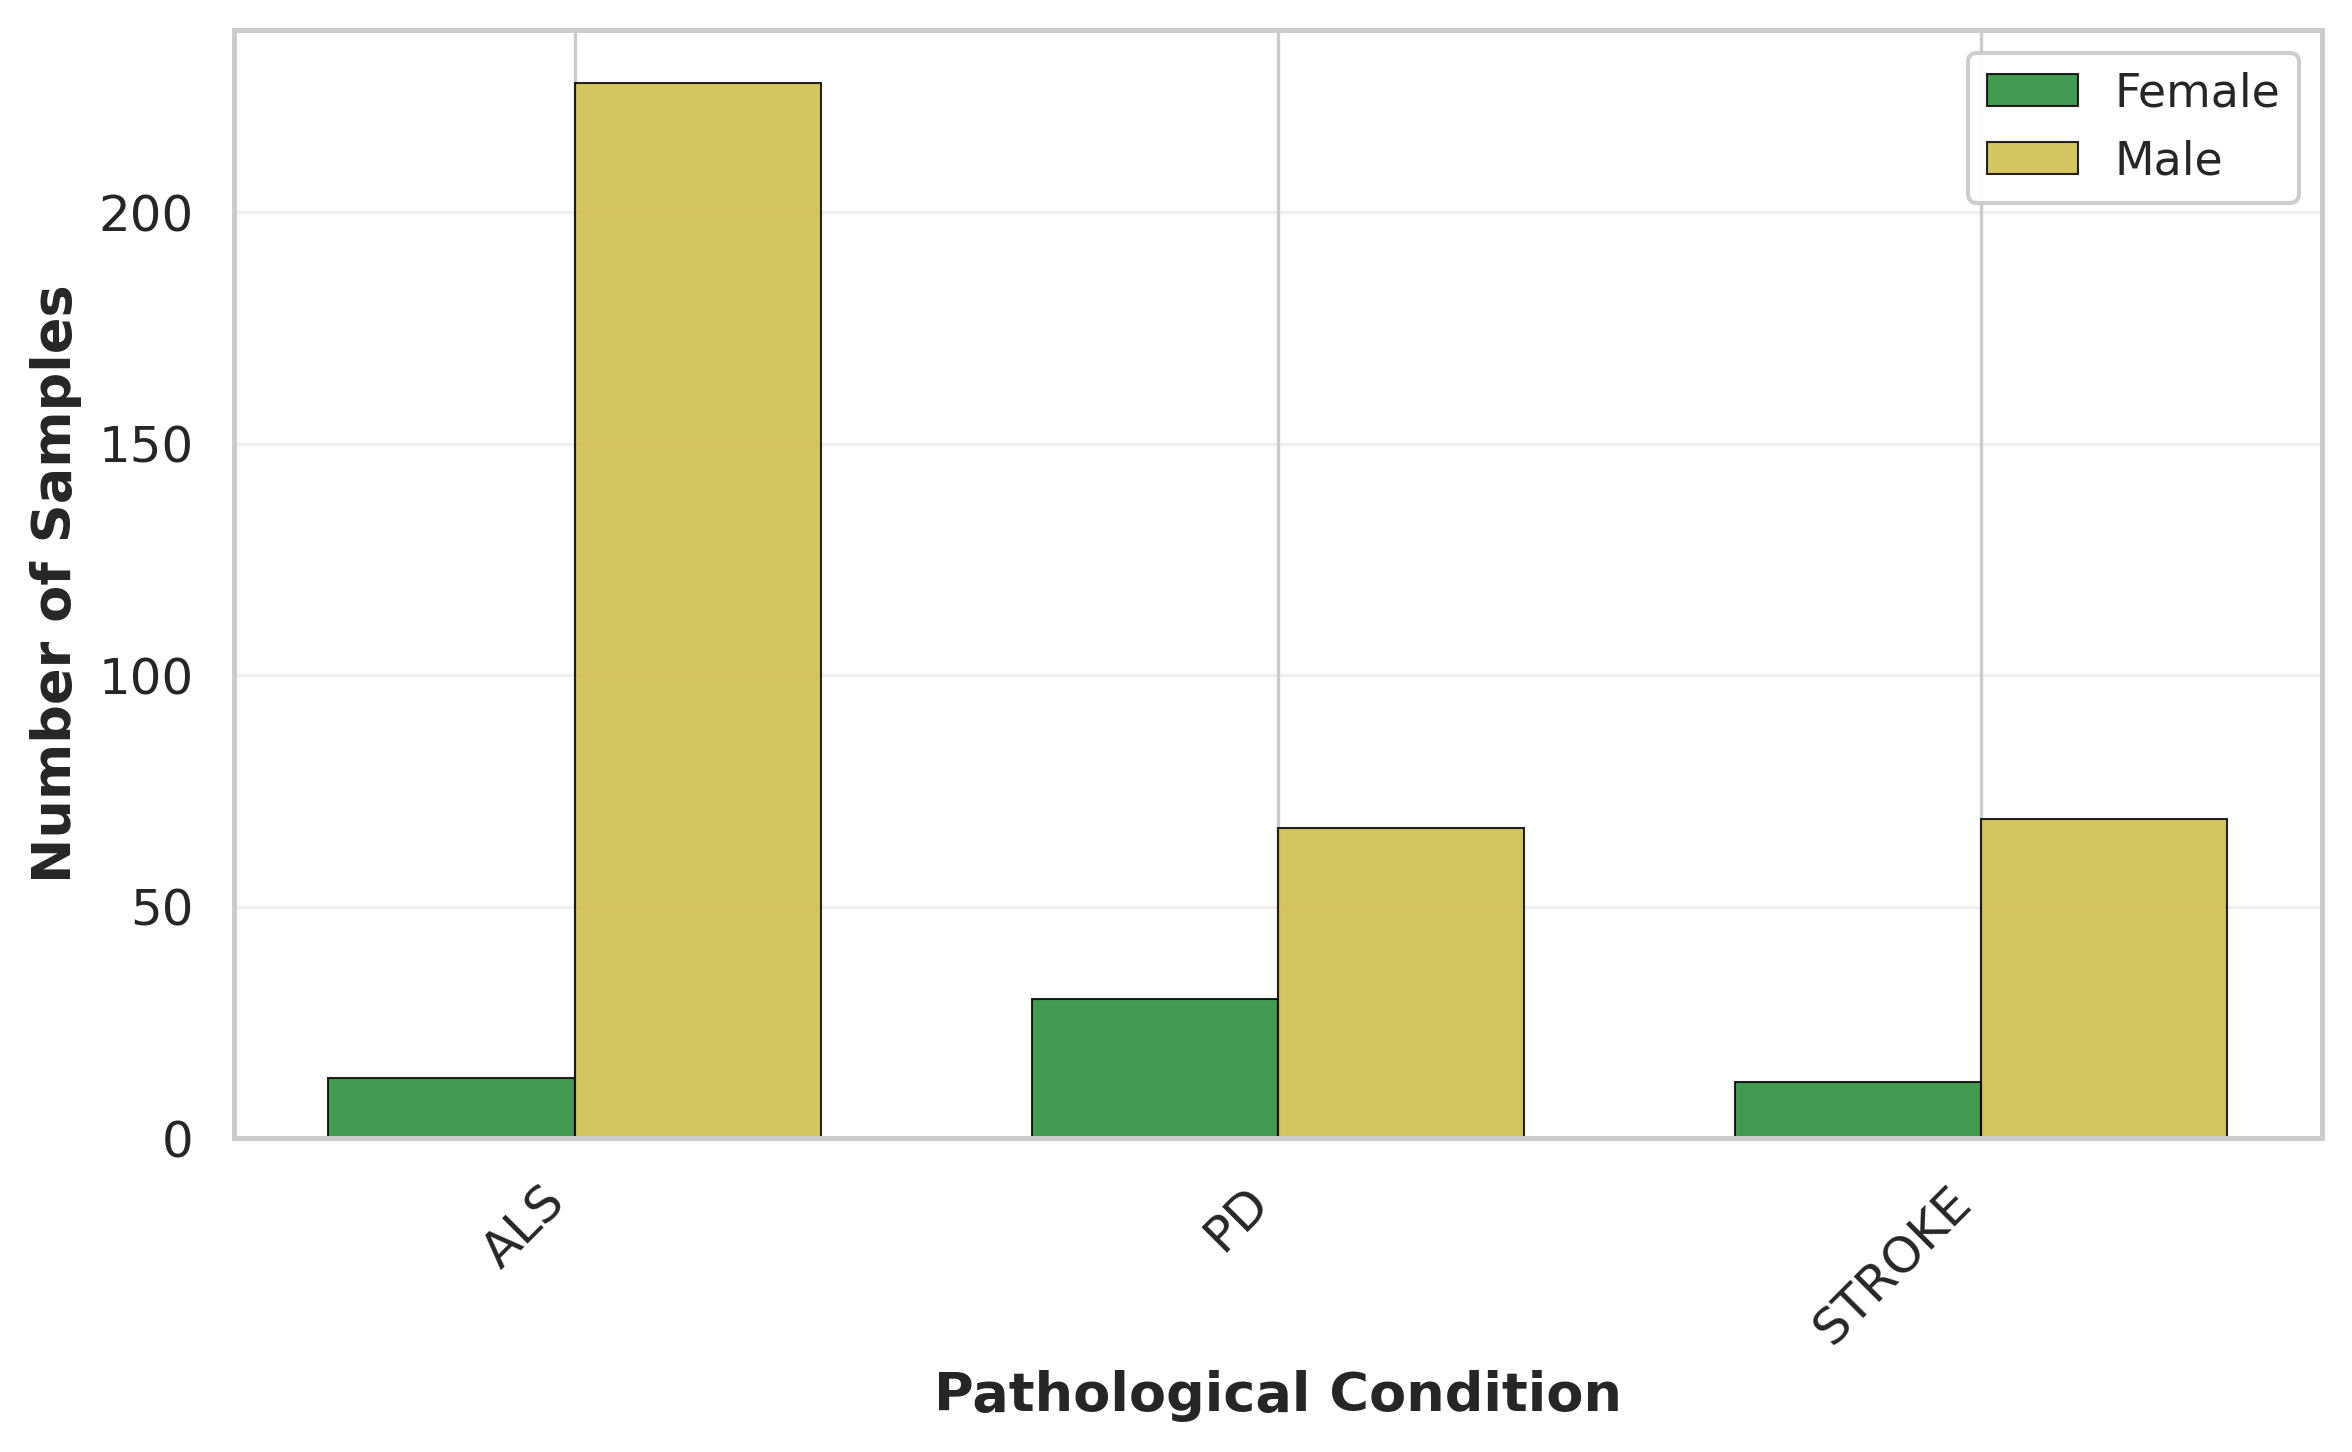

In [ ]:
# Gender Distribution per Disease - Publication Quality
if 'Sex' in df.columns and 'Disease' in df.columns:
    disease_gender = df.groupby(['Disease', 'Sex']).size().unstack(fill_value=0)
    fig, ax = plt.subplots(figsize=(8, 5))
    
    # Use distinct color-blind friendly colors (avoiding stereotypical associations)
    x = range(len(disease_gender))
    width = 0.35
    ax.bar([i - width/2 for i in x], disease_gender['Female'], width, 
           label='Female', color=COLORBLIND_PALETTE[2], alpha=0.85, edgecolor='black', linewidth=0.5)  # Green
    ax.bar([i + width/2 for i in x], disease_gender['Male'], width, 
           label='Male', color=COLORBLIND_PALETTE[3], alpha=0.85, edgecolor='black', linewidth=0.5)  # Yellow/Gold
    
    ax.set_xlabel('Pathological Condition', fontsize=13, fontweight='bold')
    ax.set_ylabel('Number of Samples', fontsize=13, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(disease_gender.index, rotation=45, ha='right', fontsize=12)
    ax.legend(fontsize=11, framealpha=0.95)
    ax.grid(True, alpha=0.3, axis='y')
    
    print("\nGender distribution per disease:")
    print(disease_gender)
    
    plt.show()

## Intelligibility Distribution

Saved: ../notebooks/images/dss/05_intelligibility_by_disease_heatmap.pdf


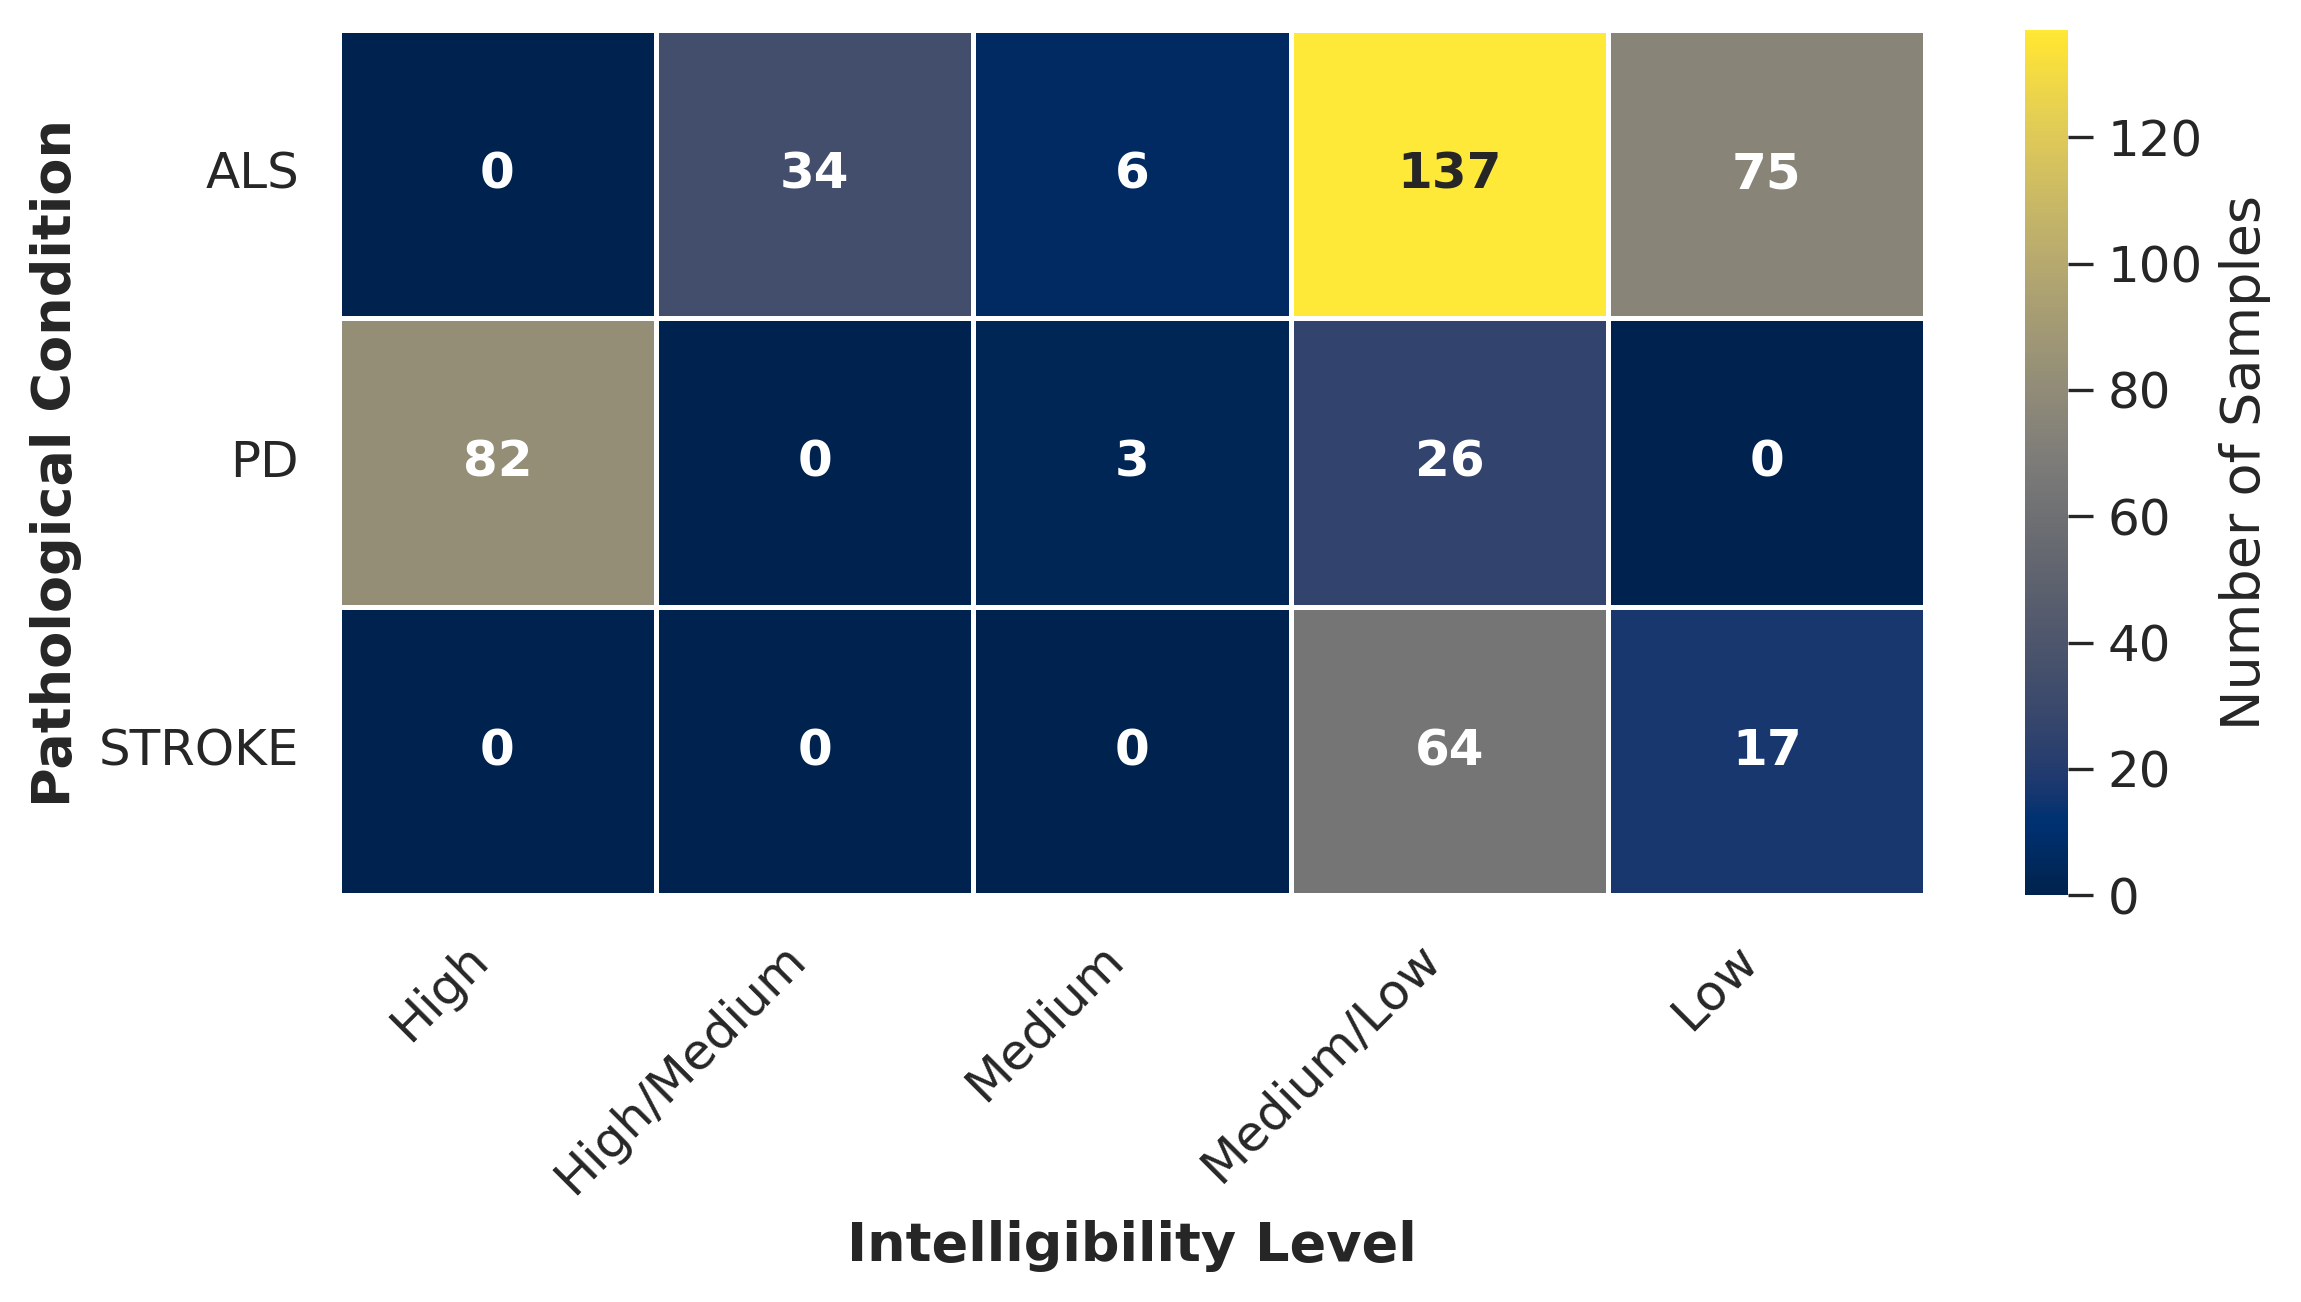


Number of samples per Disease and Intelligibility level:
Intelligibility  High  High/Medium  Medium  Medium/Low  Low
Disease                                                    
ALS                 0           34       6         137   75
PD                 82            0       3          26    0
STROKE              0            0       0          64   17


In [ ]:
if 'Intelligibility' in df.columns and 'Disease' in df.columns:
    intel_order = ["High", "High/Medium", "Medium", "Medium/Low", "Low"]
    disease_intel_counts = df.groupby(['Disease', 'Intelligibility']).size().unstack(fill_value=0)
    disease_intel_counts = disease_intel_counts[intel_order]
    
    # Create heatmap with color-blind friendly colormap
    # Using 'cividis' which is perceptually uniform and color-blind friendly
    fig, ax = plt.subplots(figsize=(8, 4.5))
    sns.heatmap(disease_intel_counts, annot=True, fmt='d', cmap='cividis', 
                cbar_kws={'label': 'Number of Samples'}, ax=ax, linewidths=0.8, 
                annot_kws={'size': 12, 'weight': 'bold'})
    ax.set_xlabel('Intelligibility Level', fontsize=13, fontweight='bold')
    ax.set_ylabel('Pathological Condition', fontsize=13, fontweight='bold')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=12)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=12)
    plt.show()
    
    print("\nNumber of samples per Disease and Intelligibility level:")
    print(disease_intel_counts)